In [74]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.auxiliares import *

In [75]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'OR_50_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'OR_50_tst.csv'))

y_train_ravel = y_train.ravel()
y_test_ravel = y_test.ravel()

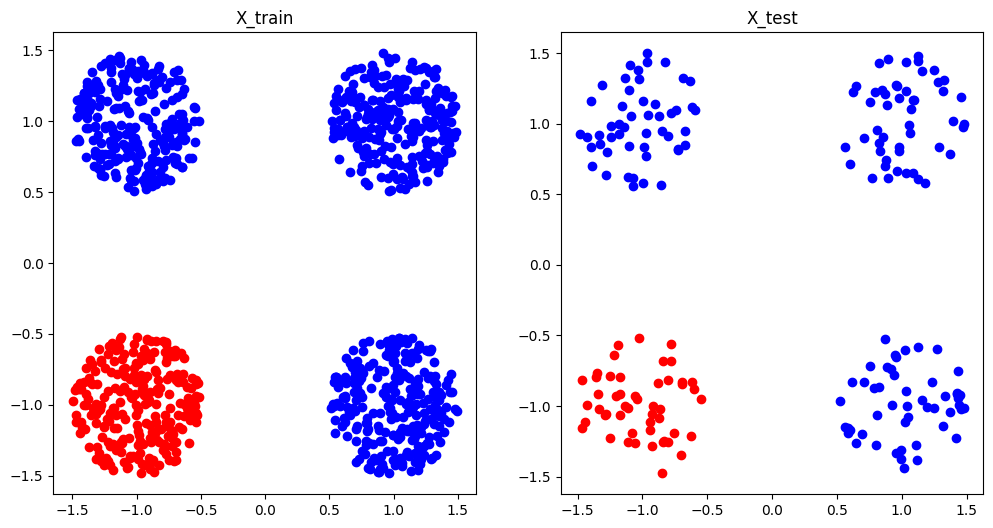

In [76]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("X_train")
plt.scatter(X_train[y_train_ravel == -1][:,0], X_train[y_train_ravel == -1][:,1], color='red')
plt.scatter(X_train[y_train_ravel == 1][:,0], X_train[y_train_ravel == 1][:,1], color='blue')

plt.subplot(1,2,2)
plt.title("X_test")
plt.scatter(X_test[y_test_ravel == -1][:,0], X_test[y_test_ravel == -1][:,1], color='red')
plt.scatter(X_test[y_test_ravel == 1][:,0], X_test[y_test_ravel == 1][:,1], color='blue')
plt.show()

In [77]:
class k_means():
    def __init__(self, n_clusters, inicializacion='random', metodo='por lotes', max_iters=500, eps=1e-3, learning_rate = 0.01):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.eps = eps
        self.learning_rate = learning_rate
        self.centroides = None
        self.historial = []
    
        match inicializacion:
            case 'random':
                self.func_inicializacion = self.random_sample

            case 'kmeans++':
                self.func_inicializacion = self.kmeans_plus_plus

            case 'uniform':
                self.func_inicializacion = self.random_uniform

        match metodo:
            case 'por lotes':
                self.fit_method = self.fit_lotes
            
            case 'online':
                self.fit_method = self.fit_online

    def random_sample(self, X):
        centroides = []
        for clase in range(self.n_clusters):
            # Nos quedamos con un dato aleatorio del dataset para el centroide
            idx = np.random.choice(X.shape[0])
            centroides.append(X[idx])
        return centroides

    def kmeans_plus_plus(self, X):
        N = X.shape[0]
        centroides = []

        idx = np.random.choice(N)
        centroides.append(X[idx])

        for it in range(1, self.n_clusters):
            distancia_maxima = []
            for i in range(N): # Recorro todos los datos
                d = 0
                for c in centroides: # Comparo con todos los centroides
                    d += np.linalg.norm(X[i] - c)
                distancia_maxima.append(d)
            centroides.append(X[np.argmax(distancia_maxima), :])
        
        return centroides
            

    def random_uniform(self, X):
        minimos = np.min(X, axis=0)
        maximos = np.max(X, axis=0)

        centroides = np.random.rand(self.n_clusters, X.shape[1]) * (maximos - minimos) + minimos
        return centroides


    def _recalcular_centroides(self, X, asignaciones):
        nuevos_centroides = np.zeros((self.n_clusters, X.shape[1]))

        for clase in range(self.n_clusters):
            X_clase = X[asignaciones == clase]
            nuevos_centroides[clase, :] = np.mean(X_clase, axis=0)
        
        return nuevos_centroides.tolist() # Pq quedamos en que es lista
            
    def fit(self, X):
        self.fit_method(X)

    def fit_lotes(self, X): # Va a ser X_train: N x features
        self.centroides = self.func_inicializacion(X)
        self.historial = []
        # distancias = N x K
        N = X.shape[0]
        K = self.n_clusters
        distancias = np.zeros((N,K))
        J = np.inf
        asignaciones = []
        for epoch in range(self.max_iters):
            # Paso 1 sería asignar los datos
            for clase in range(self.n_clusters):
                aux = np.linalg.norm(X - self.centroides[clase], axis=1)
                distancias[:,clase] = aux
            asignaciones = np.argmin(distancias, axis=1)

            self.historial.append({
                "centroides": self.centroides,
                "asignaciones": asignaciones
            })

            J_nuevo = np.sum(distancias[np.arange(N), asignaciones]**2)
            if np.abs(J - J_nuevo) < self.eps:
                break
            J = J_nuevo

            # Paso 2 sería recalcular los centroides
            self.centroides = self._recalcular_centroides(X, asignaciones)



    def fit_online(self, X):
        self.centroides = self.func_inicializacion(X)
        N = X.shape[0]
        K = self.n_clusters
        self.historial = []
        distancias = np.zeros((N,K))
        asignaciones = []
        for clase in range(K):
            aux = np.linalg.norm(X - self.centroides[clase], axis=1)
            distancias[:,clase] = aux
        asignaciones = np.argmin(distancias, axis=1)

        for epoch in range(self.max_iters):
            centroides_prev = np.array(self.centroides).copy()

            for i in range(N):
                dato = X[i, :]
                dist_indiv = []
                
                self.historial.append({
                    'centroides': self.centroides,
                    'asignaciones': asignaciones
                })

                for clase in range(K):
                    dist_indiv.append(np.linalg.norm(dato - self.centroides[clase]))
                
                idx_ganador = np.argmin(dist_indiv)
                asignaciones[i] = idx_ganador

                self.centroides[idx_ganador] += self.learning_rate * (dato - self.centroides[idx_ganador])

            cambio = np.sum(np.linalg.norm(self.centroides - centroides_prev, axis=1))
            if cambio < self.eps:
                break

    def transform(self, X):
        asignaciones = []
        N = X.shape[0]
        K = self.n_clusters
        distancias = np.zeros((N,K))

        for clase in range(self.n_clusters):
            aux = np.linalg.norm(X - self.centroides[clase], axis=1)
            distancias[:,clase] = aux
        asignaciones = np.argmin(distancias, axis=1)

        return asignaciones

In [ ]:
class RBFNN():
    def __init__(self, k_means_inicializado, n_clusters, n_clases, learning_rate=0.01, var_treatment = 'identity', funcion_activacion = 'normal'):
        self.kmeans = k_means_inicializado # Como tiene tantas variables, que venga ya inicializada la instancia
        self.n_clusters = n_clusters
        self.n_clases = n_clases
        self.medias = []

        match var_treatment:
            case 'identity':
                self.get_variance = self.variance_identity
            
            case 'identity scaled':
                self.get_variance = self.variance_scaled
            
            case 'general':
                self.get_variance = self.variance_general
        
        match funcion_activacion:
            case 'normal':
                self.func_activation = self.normal_function

    
    def variance_identity(self, X):
        return np.eye((X.shape[1], X.shape[1]))

    def variance_scaled(self, X, escala = 1):
        return np.eye((X.shape[1], X.shape[1])) * escala

    def variance_general(self, X):
        cov = np.cov(X, rowvar=False)
        cov += 1e-6 * np.eye(X.shape[1]) # regularizacion
        return cov

    def normal_function(self, x, mean, var):
        # Recibe un punto x, su cluster (ambas de tamaño n_features) 
        # y la matriz de varianza (n_features x n_features)
        M = len(x)
        # Aca aplica logaritmo natural para estabilizar valores pequeños.
        sign, escalar = (2*np.pi)**(M/2) * np.slogdet(np.linalg.det(var))
        escalar = 1/escalar

        # Acá resuelve un sistema de ecuaciones con solución matriz inversa.
        # Es más estable xd.
        exp = -0.5 * (x-mean).T @ np.linalg.solve(var, (x-mean)) @ (x-mean)
        return escalar * np.exp(exp)
    
    def fit(self, X, y):
        # Recibimos X_train
        # Paso 1: Ajustamos los centroides para las gaussianas
        #         con k-medias
        self.kmeans.fit(X)
        self.medias = self.kmeans.centroides

        # Paso 2: Entrenar la matriz de pesos de la capa de neuronas final

        pass
    

In [79]:
# PARA GRAFICAR LA EVOLUCIÓN DE LOS CENTROIDES
from matplotlib import animation
from IPython.display import HTML
import matplotlib.colors as mcolors

def crear_animacion(variables, funcion_plot, intervalo=200, paso=1):
    fig, axs = plt.subplots(1, 1, figsize=(6, 5))

    frames_indices = range(0, len(variables), paso)

    def update(frame):
        axs.clear()
        funcion_plot(variables, frame, axs)

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames_indices,
        interval=intervalo,
        blit=False
    )

    plt.close()
    return HTML(anim.to_jshtml())

def plot_kmeans_frame(historial, frame, axs, X, colores):
    ax = axs  # ahora es un solo eje

    estado = historial[frame]
    centroides = np.array(estado["centroides"])
    asignaciones = estado["asignaciones"]

    # Plot de los puntos por clase
    for i in range(len(colores)):
        puntos = X[asignaciones == i]
        ax.scatter(puntos[:,0], puntos[:,1], color=colores[i], alpha=0.6, label=f"Cluster {i}")

    for i in range(len(colores)):
        base_color = mcolors.to_rgb(colores[i])
        darker = tuple(c * 0.7 for c in base_color)  # más oscuro

        ax.scatter(centroides[i,0], centroides[i,1],
                color=darker, marker="x", s=120, label=f"Centroide {i}")

    ax.set_title(f"Frame {frame}")
    ax.legend()
    ax.grid()

def plot_wrapper_kmeans(X, colores):
    def plot(historial, frame, axs):
        plot_kmeans_frame(historial, frame, axs, X, colores)
    return plot

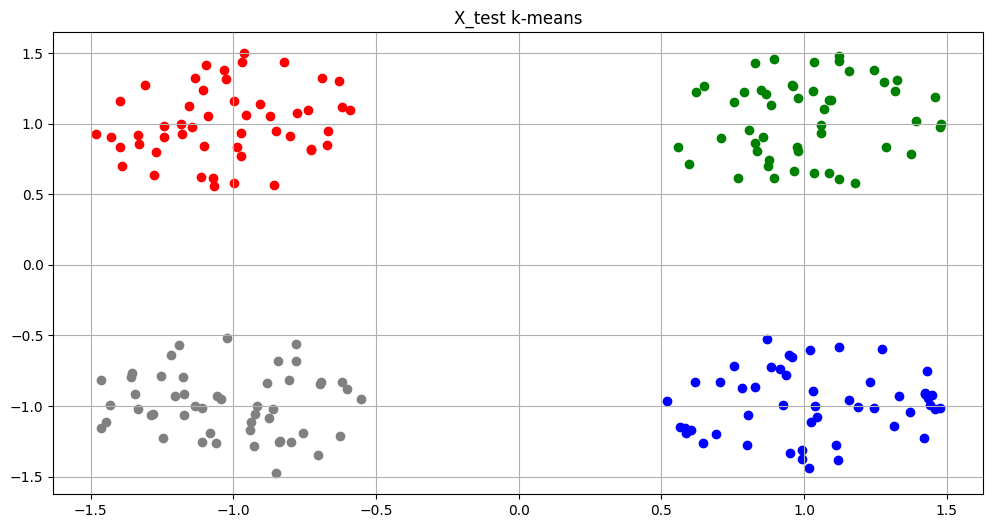

In [80]:
n_clases = 4
colores = ["red", "green", "blue", "gray"]
K_MEANS = k_means(n_clases, inicializacion='random', metodo='online', max_iters=300, eps = 1)

K_MEANS.fit(X_train)
asignaciones = K_MEANS.transform(X_test)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test k-means")

for i in range(n_clases):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()

In [92]:
colores = ["red", "green", "blue", "gray"]

historial = K_MEANS.historial
print(len(historial))

anim = crear_animacion(
    historial,
    plot_wrapper_kmeans(X_train, colores),
    intervalo=200,
    paso = 1
)

anim

5


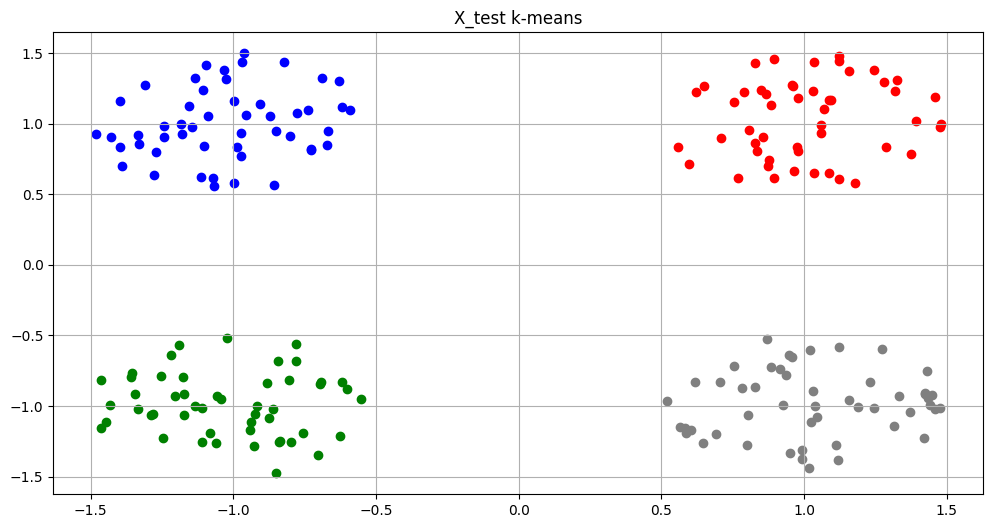

In [93]:
n_clases = 4
colores = ["red", "green", "blue", "gray"]
K_MEANS = k_means(n_clases, 'kmeans++')

K_MEANS.fit(X_train)
asignaciones = K_MEANS.transform(X_test)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test k-means")

for i in range(n_clases):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()

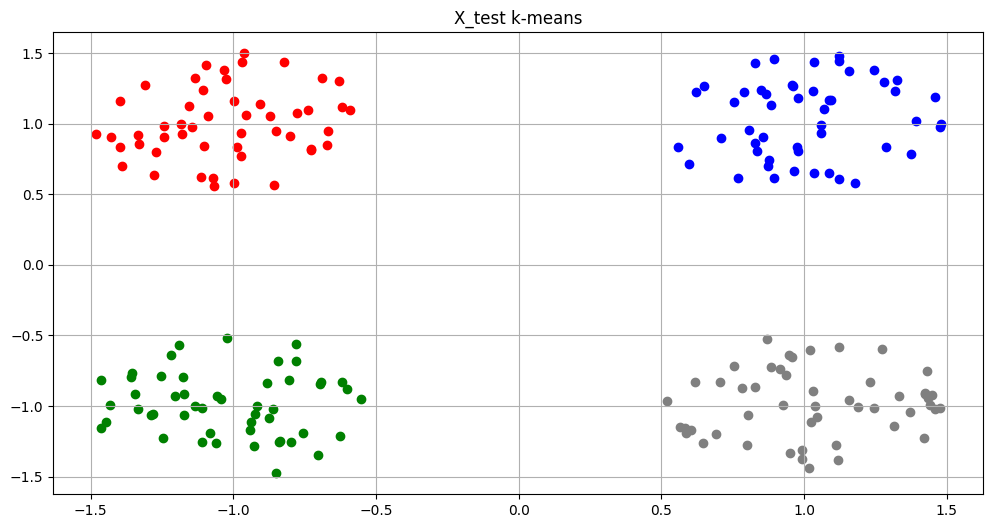

In [83]:
n_clases = 4
colores = ["red", "green", "blue", "gray"]
K_MEANS = k_means(n_clases, 'uniform')

K_MEANS.fit(X_train)
asignaciones = K_MEANS.transform(X_test)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test k-means")

for i in range(n_clases):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()